<a href="https://colab.research.google.com/github/Akanksha131313/EMPLOYABILITY-PLACEMENT_PREDICTION--RISK_MODEL/blob/main/EMPLOYABILITY_PLACEMENT_PREDICTION_(RISK_MODEL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EMPLOYABILITY / PLACEMENT PREDICTION (RISK MODEL) -**

In [1]:
# Import libraries -
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Dataset -
df = pd.read_csv("/content/sample_data/employability_prediction_data.csv")
df.head()

,CGPA,Aptitude_Score,Technical_Score,Communication_Score,Internships,Backlogs,Certifications,Employable
0,7.19,44,49,57,0,0,3,0
1,9.78,57,69,54,1,3,0,0
2,8.79,67,95,83,3,0,4,1
3,8.19,81,98,55,0,1,4,1
4,6.20,61,85,66,1,4,0,0


#### **Data Cleaning -**

In [3]:
df.isnull().sum()
df.dtypes

,0
CGPA,float64
Aptitude_Score,int64
Technical_Score,int64
Communication_Score,int64
Internships,int64
Backlogs,int64
Certifications,int64
Employable,int64


In [4]:
df.duplicated().sum()

np.int64(0)

#### **Basic EDA (Charts) -**

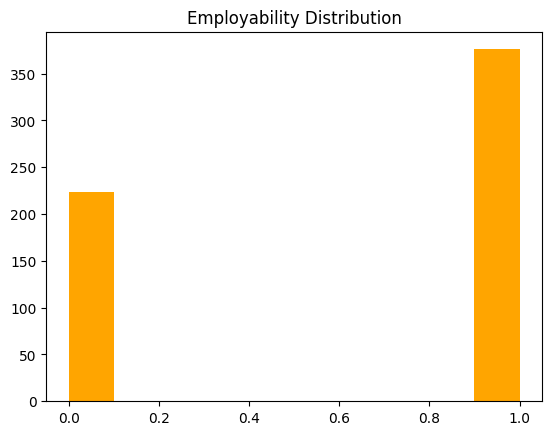

In [6]:
#Employability Distribution
plt.figure()
plt.hist(df["Employable"], color= "Orange")
plt.title("Employability Distribution")
plt.show()

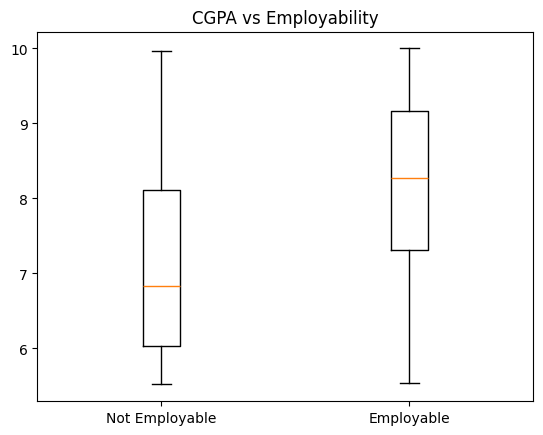

In [7]:
#CGPA vs Employability
plt.figure()
plt.boxplot([df[df["Employable"]==0]["CGPA"], df[df["Employable"]==1]["CGPA"]])
plt.xticks([1,2], ["Not Employable", "Employable"])
plt.title("CGPA vs Employability")
plt.show()

#### **Feature & Target Split -**

In [8]:
X = df.drop("Employable", axis=1)

In [9]:
y = df["Employable"]

#### **Train Test Split -**
NOTE : To maintain the class balance , we use 'Stratify' bcz it's important for risk models

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#### **Baseline Model : Logistic Regression -**

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#### **Tree-Based Model : Random Forest -**

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### **Model Evaluation (Risk Focus) -**

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# a) Classification Report :
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81        56
           1       0.89      0.88      0.89        94

    accuracy                           0.86       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.86      0.86      0.86       150

Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        56
           1       0.95      1.00      0.97        94

    accuracy                           0.97       150
   macro avg       0.97      0.96      0.96       150
weighted avg       0.97      0.97      0.97       150



In [15]:
# b)Confusion Matrix
confusion_matrix(y_test, y_pred_rf)

array([[51,  5],
       [ 0, 94]])

#### **Feature Importance (Risk Drivers) -**

In [16]:
importances = rf.feature_importances_
features = X.columns

pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(by="Importance", ascending=False)

,Feature,Importance
0,CGPA,0.210294
1,Aptitude_Score,0.207520
2,Technical_Score,0.202696
5,Backlogs,0.168088
4,Internships,0.103759
3,Communication_Score,0.072351
6,Certifications,0.035292
